# 📊 Sektör Analizi Notebook'u

## Amaç

Bu notebook, **Borsa İstanbul (BIST)** bünyesindeki belirli bir sektördeki tüm şirketleri finansal veriler üzerinden karşılaştırmalı olarak analiz etmek amacıyla geliştirilmiştir.

---

## Neler Analiz Edilir?

| Analiz Başlığı | Açıklama |
|---|---|
| **Büyüme Oranları** | Şirketlerin gelir, kâr ve varlık bazında dönemsel büyüme hızları |
| **Karlılık Rasyoları** | Brüt kâr marjı, FAVÖK marjı, net kâr marjı karşılaştırmaları |
| **Değerleme Çarpanları** | F/K, FD/FAVÖK, PD/DD gibi piyasa değerleme metrikleri |
| **Hedef Fiyat Analizi** | Sektör medyanı veya toplam üzerinden hesaplanan hedef fiyat tahmini |
| **Sektör Skor Kartı** | Her şirket için hesaplanan bileşik finansal skor ve sektör içi sıralama |
| **Görsel Panolar** | Bar grafikleri ve heatmap'ler ile sektör karşılaştırma görselleri |

---

## Nasıl Çalışır?

1. Notebook çalıştırıldığında sektör listesi görüntülenir; ilgili sektör numarası girilir.
2. Seçilen sektördeki tüm şirketlerin finansal verileri `balancesheet` ve `yfinance` kütüphaneleri aracılığıyla otomatik çekilir.
3. Finansal oranlar hesaplanır, şirketler karşılaştırılır ve sonuçlar tablo ile grafik olarak sunulur.

> **Not:** Sektör analizi için herhangi bir harici API anahtarı (EVDS vb.) gerekmemektedir.

---

## Bağımlılıklar

```
pandas · numpy · matplotlib · seaborn · yfinance · balancesheet
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from balancesheet import bilanco_cekme
import yfinance as yf
import warnings
from pathlib import Path
import re
from concurrent.futures import ThreadPoolExecutor, as_completed
from app.financial_metrics import (
    calculate_coverage_and_export_ratios,
    dupont_analizi_donemsel,
    piotroski_f_skoru,
    relative_discount_pct,
    select_column_occurrence,
    split_adjusted_paid_capital,
    prepare_split_consistent_prices,
    yf_download_safe,
)
warnings.filterwarnings("ignore")
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', None)

İşlem başladı
********** UYARI **********

Sektör seşimi yapınız.

1 - Aracı Kurumlar
2 - Bilgisayar Toptancılığı
3 - Boya
4 - Cam
5 - Çimento
6 - Dayanıklı Tüketim
7 - Demir-Çelik Döküm
8 - Demir-Çelik Temel
9 - Deri Giyim
10 - Eğlence Hizmetleri
11 - Elektrik - Doğalgaz Dağıtım
12 - Elektrik Enerji Ürt.Teçh/Tesis Kurulum
13 - Elektrik Üretim
14 - Endüstriyel Makine -Teçhizat Üretim
15 - Endüstriyel Tekstil
16 - Gıda
17 - GYO
18 - Havayolları ve Hizm.
19 - Hayvancılık
20 - Holdingler
21 - İletişim
22 - İletişim Cihazları
23 - İnşaat Malzemeleri
24 - İnşaat- Taahhüt
25 - Kablo
26 - Kağıt Ürünleri
27 - Kırtasiye
28 - Kimyasal Ürün
29 - Madencilik
30 - Medya
31 - Meşrubat / İçecek
32 - Mobilya
33 - Otomotiv
34 - Otomotiv Lastiği
35 - Otomotiv Parçası
36 - Pazarlama
37 - Perakande - Ticaret
38 - Petrol
39 - Sağlık ve İlaç
40 - Savunma
41 - Seramik
42 - Tarım Kimyasalları
43 - Teknoloji
44 - Tekstil Entegre
45 - Turizm
46 - Ulaştırma-Lojistik
47 - Yatırım Ortaklıkları


Sektör numarası:  12


********** UYARI **********

Hedef fiyat hesaplaması sektör gelir tablosu kalemlerinin toplamından hesaplanması için TOPLAM'ı seçiniz.

Eğer hedef fiyat hesaplamasının sektör rasyolarının medyanından hesaplanmasını isterseniz MEDIAN'ı seçiniz.

1 - TOPLAM
2 - MEDIAN


Seçim numarası:  1


********** UYARI **********

Analizin Excel dosyası olarak kaydedilmesini istiyorsanız EVET'i seçiniz.

1 - EVET
2 - HAYIR


Seçim numarası:  1



Elektrik Enerji Ürt.Teçh/Tesis Kurulum Sektörü Analizi

                 Ana Ortaklığa Ait Özkaynaklar    Ödenmiş Sermaye  \
Kod                                                                 
SMRTG                         4,633,827,218.00     605,880,000.00   
ORGE                          3,964,498,892.00      80,000,000.00   
GESAN                        13,639,026,000.00     460,000,000.00   
SAYAS                         1,231,481,752.00      77,250,000.00   
CWENE                        16,106,307,516.00   1,078,290,009.00   
EUPWR                        10,543,794,000.00     660,000,000.00   
KLYPV                        13,296,169,656.00     411,441,018.00   
ASTOR                        33,280,133,403.00     998,000,000.00   
ALFAS                         5,286,209,835.00     368,000,000.00   
ULUSE                           196,772,712.00      80,000,000.00   
MAGEN                        12,924,292,007.00   2,950,000,000.00   
EMKEL                           979,835,640.00

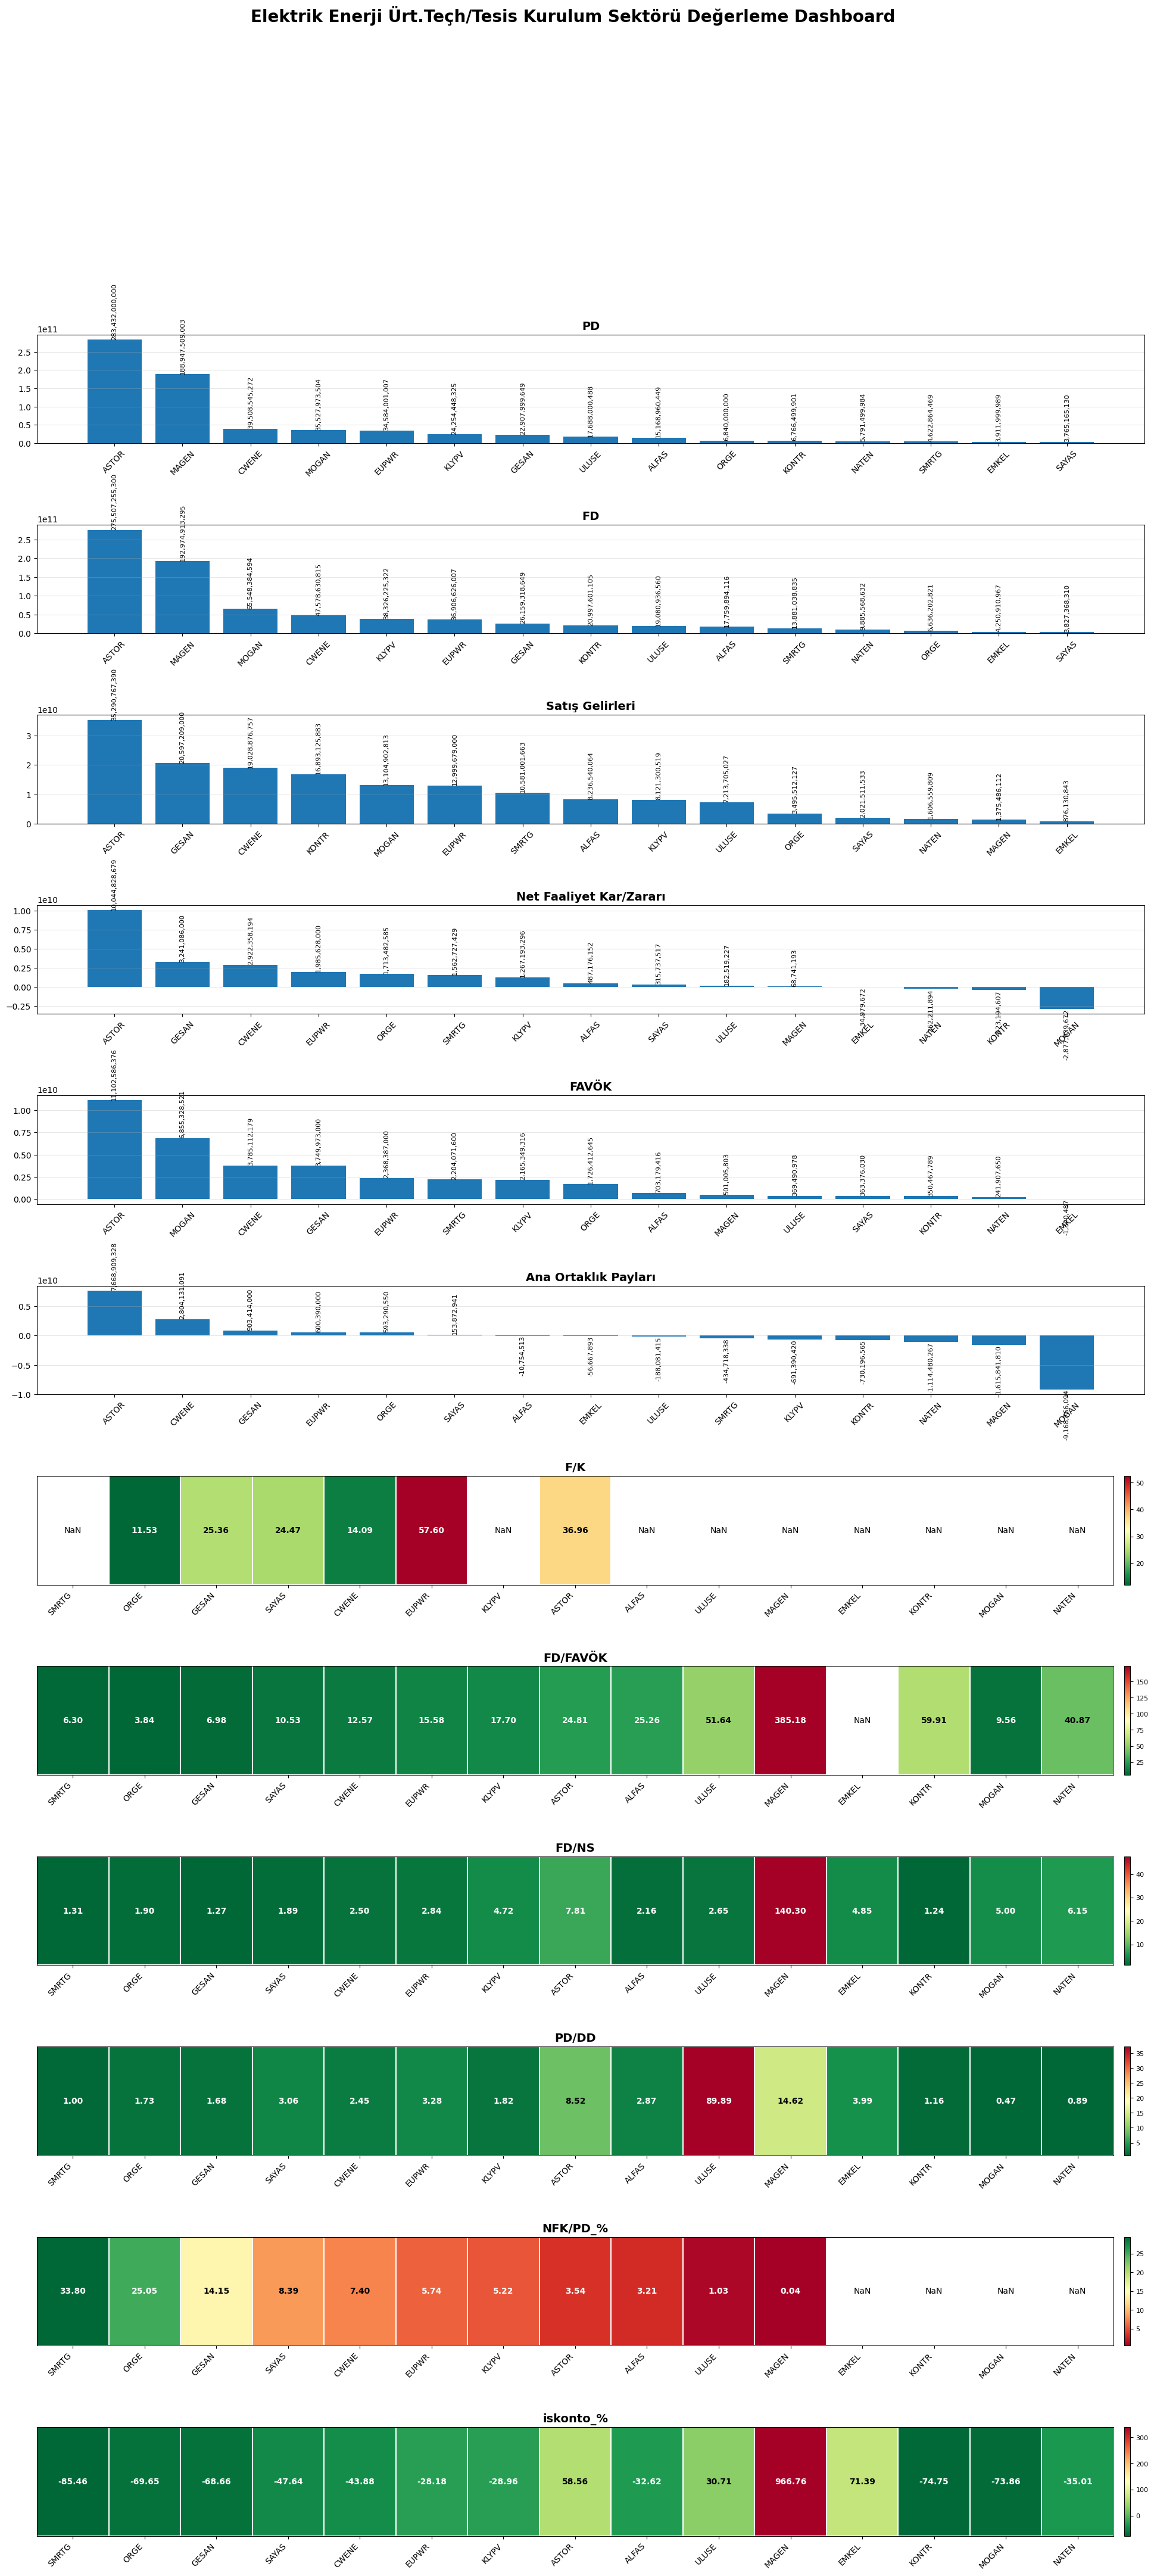

********** UYARI **********

Analizin Excel dosyası olarak kaydedilmesini istiyorsanız EVET'i seçiniz.

1 - EVET
2 - HAYIR


Seçim numarası:  1



Elektrik Enerji Ürt.Teçh/Tesis Kurulum Sektörü Analizi

                 Ana Ortaklığa Ait Özkaynaklar    Ödenmiş Sermaye  \
Kod                                                                 
SMRTG                         4,633,827,218.00     605,880,000.00   
ORGE                          3,964,498,892.00      80,000,000.00   
GESAN                        13,639,026,000.00     460,000,000.00   
SAYAS                         1,231,481,752.00      77,250,000.00   
CWENE                        16,106,307,516.00   1,078,290,009.00   
EUPWR                        10,543,794,000.00     660,000,000.00   
KLYPV                        13,296,169,656.00     411,441,018.00   
ASTOR                        33,280,133,403.00     998,000,000.00   
ALFAS                         5,286,209,835.00     368,000,000.00   
ULUSE                           196,772,712.00      80,000,000.00   
MAGEN                        12,924,292,007.00   2,950,000,000.00   
EMKEL                           979,835,640.00

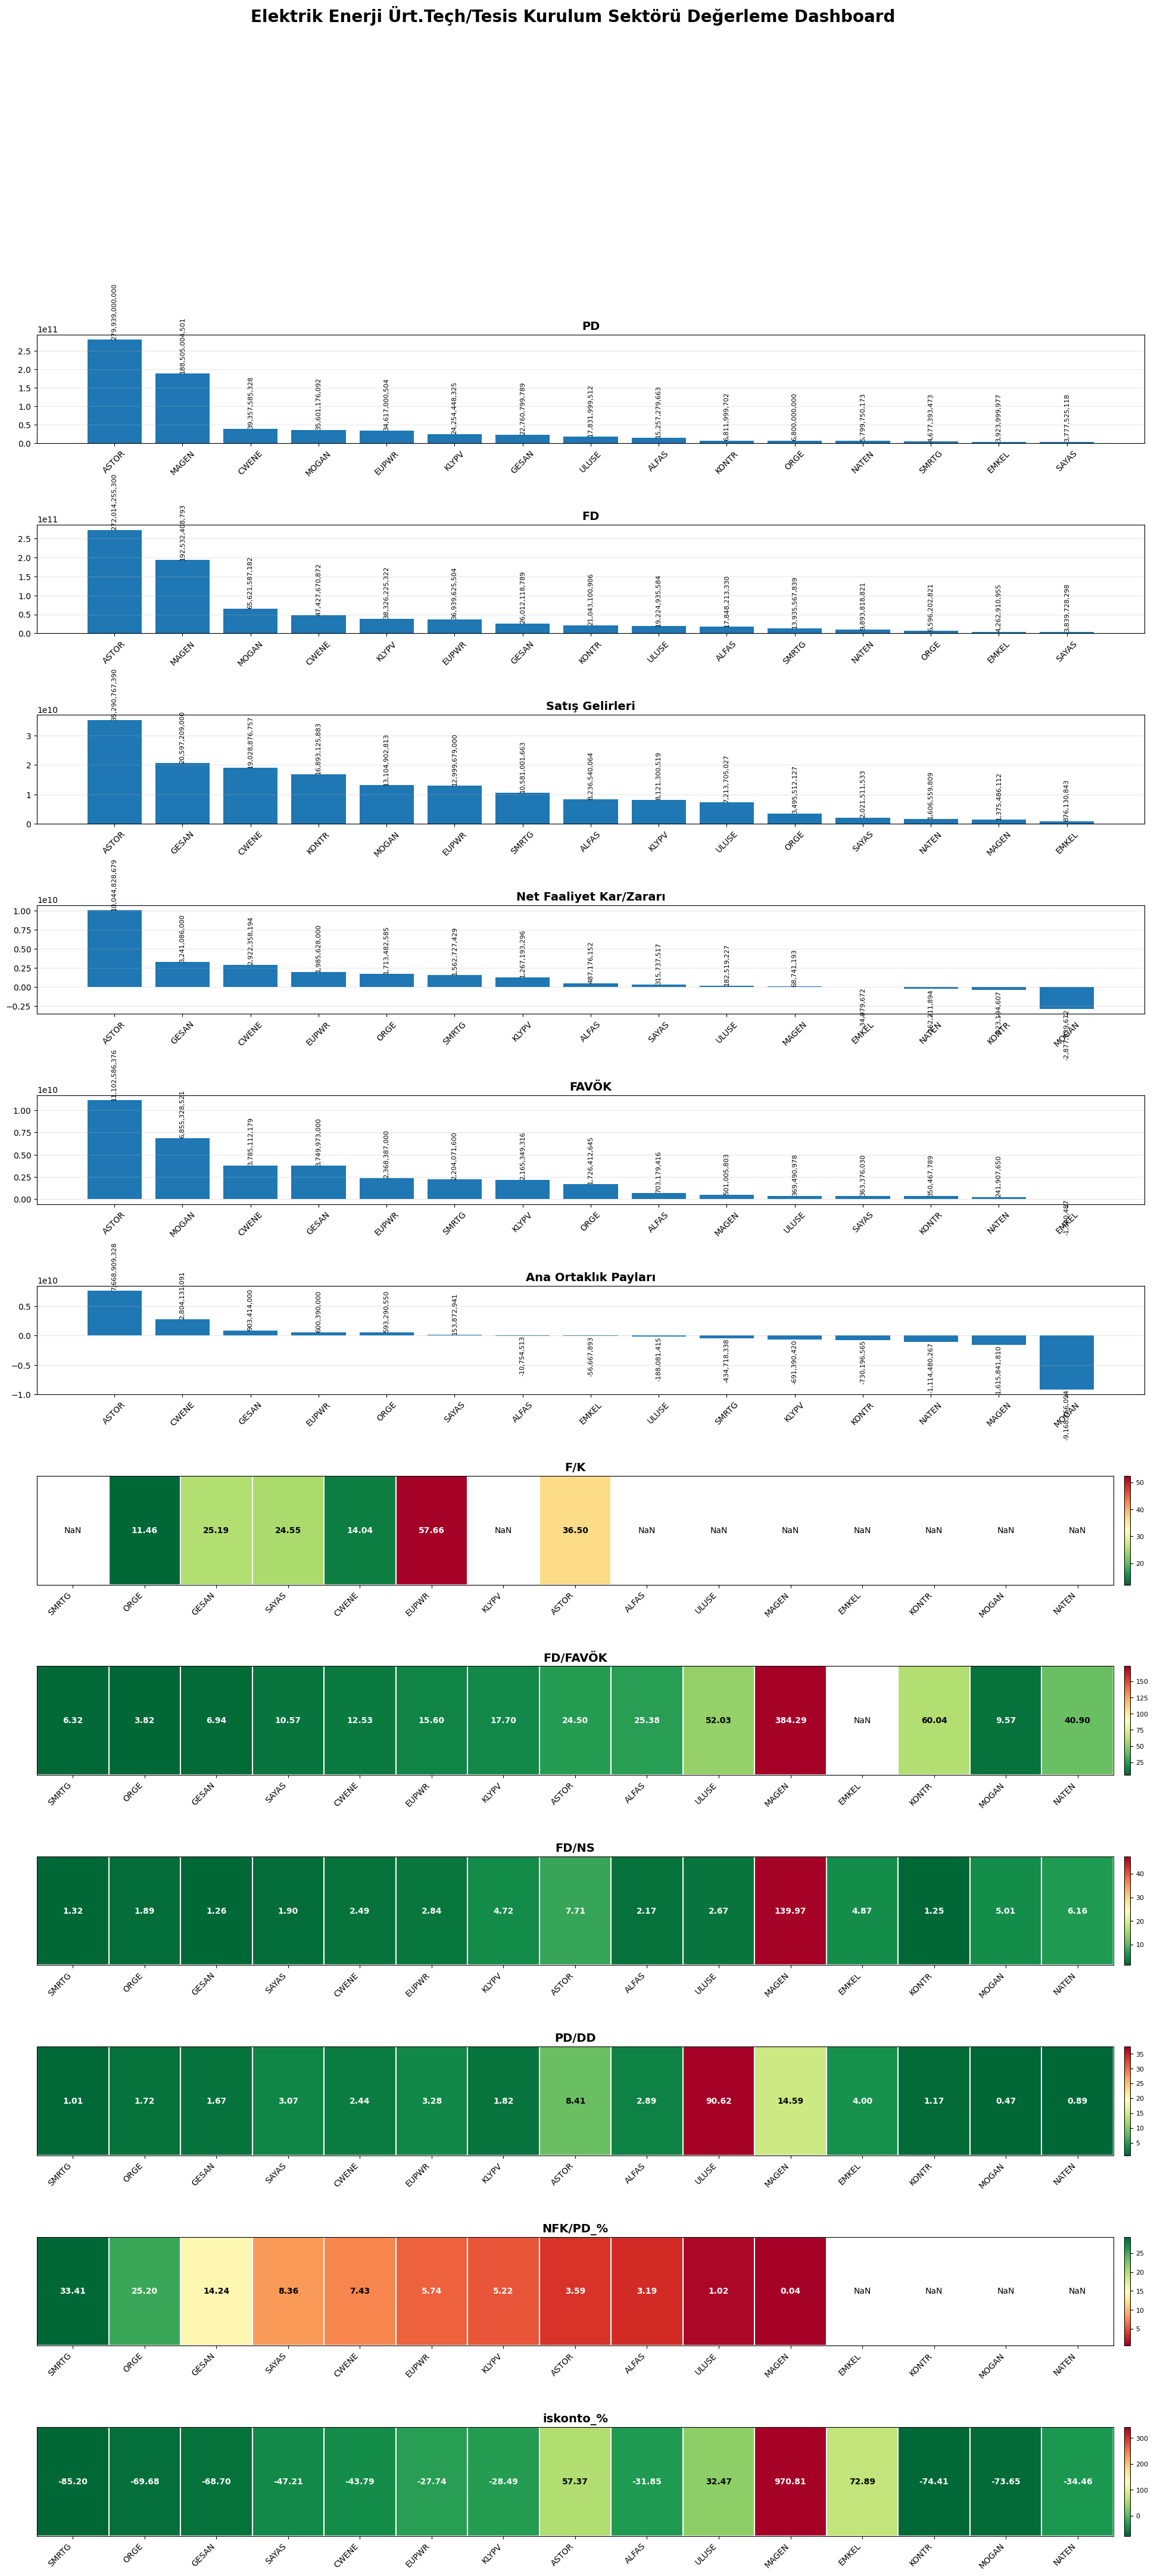

In [ ]:
def gelir_tablosu(df, ceyrek=False, yillik=False):
    gelir_tab = df.loc[:, df.columns[df.columns.tolist().index("Satış Gelirleri"):]].copy()
    gelir_tab["dönem"] = gelir_tab.index.month
    gelir_tab["yil"] = gelir_tab.index.year
    if ceyrek:
        cols = gelir_tab.select_dtypes(include="number").columns.drop(["dönem", "yil"])
        gelir_tab_cey = gelir_tab.copy()
        mask = gelir_tab_cey["dönem"] != 3
        gelir_tab_cey.loc[mask, cols] = (gelir_tab_cey.groupby("yil")[cols].diff())
        return gelir_tab_cey
    elif yillik:
        gelir_tab_cey = gelir_tab.copy()
        cols = gelir_tab_cey.select_dtypes(include="number").columns.drop(["dönem", "yil"])
        mask = gelir_tab_cey["dönem"] != 3
        gelir_tab_cey.loc[mask, cols] = (gelir_tab_cey.groupby("yil")[cols].diff())
        gelir_tab_yil =gelir_tab_cey.copy()
        gelir_tab_yil[cols] = gelir_tab_cey[cols].rolling(window=4).sum()
        gelir_tab_yil.dropna(inplace=True)
        return gelir_tab_yil
    else:
        return gelir_tab

def bilanco_yillik(df, gelir_tab_yil):
    bilanco = df[df.columns.tolist()[:df.columns.tolist().index("Satış Gelirleri")]]
    bilanco = bilanco.loc[gelir_tab_yil.index,:]
    bilanco = bilanco.loc[:, ~bilanco.columns.duplicated()]
    new_df = bilanco.merge(gelir_tab_yil, how="inner", left_index=True, right_index=True)
    new_df["uzun_vadeli_finansal_borc"] = select_column_occurrence(
        df, "  Finansal Borçlar", occurrence=1, default=0.0
    ).reindex(new_df.index)
    new_df["uzun_vadeli_diger_finansal_yukumluluk"] = select_column_occurrence(
        df, "  Diğer Finansal Yükümlülükler", occurrence=1, default=0.0
    ).reindex(new_df.index)
    return new_df


def degerleme_tablosu(new_df, hisse, bilanco_df=None, piotroski_hesapla=True):
    # Tarihsel sermaye, fiyat verisindeki bölünmelerle aşağıda aynı baza getirilir.
    
    new_df["net_borc"] = (
        new_df["  Finansal Borçlar"]
        + new_df["  Diğer Finansal Yükümlülükler"]
        + new_df["uzun_vadeli_finansal_borc"]
        + new_df["uzun_vadeli_diger_finansal_yukumluluk"]
        - new_df["  Nakit ve Nakit Benzerleri"]
        - new_df["  Finansal Yatırımlar"]
    )


    new_df = new_df.copy()
    new_df.index = pd.to_datetime(new_df.index)
    new_df = new_df.sort_index()
    sirket = hisse + ".IS"
    
    prices_raw = yf_download_safe(
        sirket,
        start=new_df.index.min() - pd.Timedelta(days=10),
        end=pd.Timestamp.today().normalize() + pd.Timedelta(days=1),
        auto_adjust=False,
        actions=True,
        progress=False,
        multi_level_index=False
    )
    
    split_events = (
        prices_raw["Stock Splits"]
        if "Stock Splits" in prices_raw.columns
        else pd.Series(dtype=float)
    )
    new_df["  Ödenmiş Sermaye"], new_df["sermaye_duzeltme_katsayisi"] = (
        split_adjusted_paid_capital(new_df["  Ödenmiş Sermaye"], split_events)
    )
    new_df["hbk"] = (
        new_df["Ana Ortaklık Payları"] / new_df["  Ödenmiş Sermaye"]
    )
    prices = prepare_split_consistent_prices(prices_raw)
    
    new_df.index = new_df.index.astype("datetime64[s]")
    prices.index = prices.index.astype("datetime64[s]")
    
    df = pd.merge_asof(
        new_df.sort_index(),
        prices.sort_index(),
        left_index=True,
        right_index=True,
        direction="backward"
    )
    
    # Aynı fiyat serisinin son satırı güncel işlem fiyatını da içerir;
    # ikinci bir yfinance çağrısına gerek yoktur.
    if not prices.empty:
        guncel_fiyat = prices["fiyat"].iloc[-1]
        guncel_duzeltilmis_fiyat = prices["duzeltilmis_fiyat"].iloc[-1]
        guncel_toplam_getiri_fiyati = prices["toplam_getiri_fiyati"].iloc[-1]

        df.loc[df.index[-1], "fiyat"] = guncel_fiyat
        df.loc[df.index[-1], "duzeltilmis_fiyat"] = guncel_duzeltilmis_fiyat
        df.loc[df.index[-1], "toplam_getiri_fiyati"] = guncel_toplam_getiri_fiyati
    
    df["getiri"] = df["toplam_getiri_fiyati"].pct_change(fill_method=None)

    df["PD"] = df["  Ödenmiş Sermaye"] * df["duzeltilmis_fiyat"]
    df["FD"] = df["PD"] + df["net_borc"]
    df["PD/DD"] = df["PD"] / df["  Ana Ortaklığa Ait Özkaynaklar"]
    df["F/K"] = df["duzeltilmis_fiyat"] / df["hbk"]
    df["FD/FAVÖK"] = df["FD"] / df["FAVÖK"]
    df["PD/NFK"] = df["PD"] / df["Net Faaliyet Kar/Zararı"]
    df["FD/NS"] = df["FD"] / df["Satış Gelirleri"]
    df["NFK/PD_%"] = (df["Net Faaliyet Kar/Zararı"] / df["PD"])*100
    df["PD/NS"] = df["PD"] / df["Satış Gelirleri"]

    # negatifleri NaN yap
    degerleme_cols = ["PD/DD", "F/K", "FD/FAVÖK", "PD/NFK", "FD/NS", "PD/NS"]
    df[degerleme_cols] = df[degerleme_cols].mask(df[degerleme_cols] < 0, np.nan)

    # Brüt kâr marjı, ROA ve cari oran: DuPont ayrıştırması ve Piotroski
    # F-Skoru için gereken ham oranlar (şirket analizindeki oran_rasyo_hesaplama
    # ile aynı formüller, tek kaynaktan bakım için app.financial_metrics kullanılır).
    df["brüt_kar_marjı_%"] = (df["BRÜT KAR (ZARAR)"] / df["Satış Gelirleri"]) * 100
    df["ortalama_toplam_aktifler"] = (df["TOPLAM VARLIKLAR"] + df["TOPLAM VARLIKLAR"].shift(1)) / 2
    df["aktif_karliligi_%"] = (df["Ana Ortaklık Payları"] / df["ortalama_toplam_aktifler"]) * 100
    df["cari_oran"] = df["Dönen Varlıklar"] / df["Kısa Vadeli Yükümlülükler"]
    df = calculate_coverage_and_export_ratios(df)

    dupont_df = dupont_analizi_donemsel(df)
    df = df.join(dupont_df)

    if piotroski_hesapla:
        piotroski_sonuc = piotroski_f_skoru(df)
        df.loc[df.index[-1], "Piotroski F-Skoru"] = piotroski_sonuc["score"]
    else:
        df["Piotroski F-Skoru"] = np.nan

    df2 = df.loc[[df.index[-1]], [
        "  Ana Ortaklığa Ait Özkaynaklar",
        "  Ödenmiş Sermaye",
        "net_borc",
        "duzeltilmis_fiyat",
        "PD",
        "FD",
        "Satış Gelirleri",
        "Net Faaliyet Kar/Zararı",
        "FAVÖK",
        "Ana Ortaklık Payları",
        "F/K",
        "FD/FAVÖK",
        "FD/NS",
        "PD/DD",
        "NFK/PD_%",
        "brüt_kar_marjı_%",
        "net_kar_marjı_%",
        "aktif_devir_hizi",
        "ozkaynak_carpani",
        "roe_dupont_%",
        "faiz_karsilama",
        "ihracat_oranı_%",
        "Piotroski F-Skoru",
    ]]

    df2.index = [hisse]

    # Web sektör grafiklerinde yeniden veri indirmeden kullanılmak üzere
    # şirketin yıllıklandırılmış gelir tablosu geçmişini son satır özetine ekle.
    # Bu metadata yalnız sunucu içinde tutulur; şirket geçmişleri tarayıcıya
    # ayrı ayrı gönderilmez.
    history_cols = [
        "Satış Gelirleri", "BRÜT KAR (ZARAR)",
        "Net Faaliyet Kar/Zararı", "FAVÖK", "Ana Ortaklık Payları",
    ]
    history_cols = [col for col in history_cols if col in df.columns]
    df2.attrs["sector_history"] = df[history_cols].copy()
    if isinstance(bilanco_df, pd.DataFrame) and not bilanco_df.empty:
        df2.attrs["latest_financial_period"] = pd.Timestamp(bilanco_df.index.max())
    else:
        df2.attrs["latest_financial_period"] = pd.Timestamp(df.index.max())

    return df2

def _tek_hisse_analizi(x, piotroski_hesapla=True):
    """Tek bir hisse için bilanço çekimi + değerleme (paralel çalıştırmak için)."""
    df = bilanco_cekme([x])
    gelir_tab_yil = gelir_tablosu(df, yillik=True)
    new_df = bilanco_yillik(df, gelir_tab_yil)
    new_df = degerleme_tablosu(new_df, x, df, piotroski_hesapla=piotroski_hesapla)
    return new_df

def sektor_analizi(hisseler, analiz_turu, temel_ozet, max_workers=8, piotroski_hesapla=True):
    dfs = []
    financial_dir = {}
    failed_symbols = {}
    company_histories = {}
    latest_financial_periods = {}

    # Her hisse için veri çekimi ağ (network I/O) tabanlı ve birbirinden bağımsız
    # olduğundan, thread havuzuyla paralel çalıştırılır. Bu, sıralı çalışmaya göre
    # sektördeki hisse sayısıyla orantılı süreyi büyük ölçüde kısaltır.
    with ThreadPoolExecutor(max_workers=min(max_workers, len(hisseler)) or 1) as executor:
        future_to_hisse = {
            executor.submit(_tek_hisse_analizi, x, piotroski_hesapla): x for x in hisseler
        }
        for future in as_completed(future_to_hisse):
            x = future_to_hisse[future]
            try:
                new_df = future.result()
                financial_dir[x] = new_df
                history = new_df.attrs.get("sector_history")
                latest_period = new_df.attrs.get("latest_financial_period")
                if isinstance(history, pd.DataFrame) and not history.empty:
                    company_histories[x] = history.copy()
                if latest_period is not None and not pd.isna(latest_period):
                    latest_financial_periods[x] = pd.Timestamp(latest_period)
                # DataFrame içeren attrs değerleri pd.concat sırasında eşitlik
                # karşılaştırmasına girmez; geçmişler yukarıda merkezi sözlüklere alındı.
                new_df.attrs.clear()
                dfs.append(new_df)
            except Exception as e:
                failed_symbols[x] = str(e)
                print(f"Hata: {x}: {e}")

    if dfs:
        sektor_df = pd.concat(dfs)
        sektor_df = sektor_df.sort_values(by="NFK/PD_%", ascending=False)
        sektor_df = sektor_df.reset_index().rename(columns={"index": "Kod"})

        sektor_df = sektor_df.merge(
            temel_ozet[["Kod", "Sektör"]],
            on="Kod",
            how="left"
        )
    
        sektor_df.loc[sektor_df.index[-1]+1, "Kod"] = "SEKTÖR TOPLAM"
        sektor_df.loc[sektor_df.index[-1], "  Ana Ortaklığa Ait Özkaynaklar"] = sektor_df["  Ana Ortaklığa Ait Özkaynaklar"][:-1].sum()
        sektor_df.loc[sektor_df.index[-1], "  Ödenmiş Sermaye"] = sektor_df["  Ödenmiş Sermaye"][:-1].sum()
        sektor_df.loc[sektor_df.index[-1], "net_borc"] = sektor_df["net_borc"][:-1].sum()
        sektor_df.loc[sektor_df.index[-1], "PD"] = sektor_df["PD"][:-1].sum()
        sektor_df.loc[sektor_df.index[-1], "FD"] = sektor_df["FD"][:-1].sum()
        sektor_df.loc[sektor_df.index[-1], "Satış Gelirleri"] = sektor_df["Satış Gelirleri"][:-1].sum()
        sektor_df.loc[sektor_df.index[-1], "Net Faaliyet Kar/Zararı"] = sektor_df["Net Faaliyet Kar/Zararı"][:-1].sum()
        sektor_df.loc[sektor_df.index[-1], "FAVÖK"] = sektor_df["FAVÖK"][:-1].sum()
        sektor_df.loc[sektor_df.index[-1], "Ana Ortaklık Payları"] = sektor_df["Ana Ortaklık Payları"][:-1].sum()
        sektor_df.loc[sektor_df.index[-1], "F/K"] = sektor_df.loc[sektor_df.index[-1], "PD"] / sektor_df.loc[sektor_df.index[-1], "Ana Ortaklık Payları"]
        sektor_df.loc[sektor_df.index[-1], "FD/FAVÖK"] = sektor_df.loc[sektor_df.index[-1], "FD"] / sektor_df.loc[sektor_df.index[-1], "FAVÖK"]
        sektor_df.loc[sektor_df.index[-1], "FD/NS"] = sektor_df.loc[sektor_df.index[-1], "FD"] / sektor_df.loc[sektor_df.index[-1], "Satış Gelirleri"]
        sektor_df.loc[sektor_df.index[-1], "PD/DD"] = sektor_df.loc[sektor_df.index[-1], "PD"] / sektor_df.loc[sektor_df.index[-1], "  Ana Ortaklığa Ait Özkaynaklar"]
        sektor_df.loc[sektor_df.index[-1], "NFK/PD_%"] = (sektor_df.loc[sektor_df.index[-1], "Net Faaliyet Kar/Zararı"] / sektor_df.loc[sektor_df.index[-1], "PD"]) * 100
        if "ihracat_oranı_%" in sektor_df.columns:
            export_values = pd.to_numeric(sektor_df["ihracat_oranı_%"][:-1], errors="coerce")
            export_weights = pd.to_numeric(sektor_df["Satış Gelirleri"][:-1], errors="coerce").clip(lower=0)
            valid_export = export_values.notna() & export_weights.gt(0)
            if valid_export.any():
                sektor_df.loc[sektor_df.index[-1], "ihracat_oranı_%"] = np.average(export_values[valid_export], weights=export_weights[valid_export])
        if "faiz_karsilama" in sektor_df.columns:
            coverage = pd.to_numeric(sektor_df["faiz_karsilama"][:-1], errors="coerce")
            favok_values = pd.to_numeric(sektor_df["FAVÖK"][:-1], errors="coerce")
            valid_coverage = coverage.notna() & coverage.ne(0) & favok_values.notna()
            implied_finance_cost = (favok_values[valid_coverage] / coverage[valid_coverage]).abs().sum()
            if implied_finance_cost > 0:
                sektor_df.loc[sektor_df.index[-1], "faiz_karsilama"] = favok_values[valid_coverage].sum() / implied_finance_cost
        sektor_df.loc[sektor_df.index[-1], "Sektör"] = sektor_df.loc[sektor_df.index[-1]-1, "Sektör"]
        degerleme_cols = ["F/K", "FD/FAVÖK", "FD/NS", "PD/DD"]
        sektor_df[degerleme_cols] = sektor_df[degerleme_cols].mask(sektor_df[degerleme_cols] < 0, np.nan)
        sektor_df.loc[sektor_df.index[-1]+1, "Kod"] = "SEKTÖR Median"
        sektor_df.loc[sektor_df.index[-1], "  Ana Ortaklığa Ait Özkaynaklar"] = sektor_df["  Ana Ortaklığa Ait Özkaynaklar"][:-2].median()
        sektor_df.loc[sektor_df.index[-1], "  Ödenmiş Sermaye"] = sektor_df["  Ödenmiş Sermaye"][:-2].median()
        sektor_df.loc[sektor_df.index[-1], "net_borc"] = sektor_df["net_borc"][:-2].median()
        sektor_df.loc[sektor_df.index[-1], "PD"] = sektor_df["PD"][:-2].median()
        sektor_df.loc[sektor_df.index[-1], "FD"] = sektor_df["FD"][:-2].median()
        sektor_df.loc[sektor_df.index[-1], "Satış Gelirleri"] = sektor_df["Satış Gelirleri"][:-2].median()
        sektor_df.loc[sektor_df.index[-1], "Net Faaliyet Kar/Zararı"] = sektor_df["Net Faaliyet Kar/Zararı"][:-2].median()
        sektor_df.loc[sektor_df.index[-1], "FAVÖK"] = sektor_df["FAVÖK"][:-2].median()
        sektor_df.loc[sektor_df.index[-1], "Ana Ortaklık Payları"] = sektor_df["Ana Ortaklık Payları"][:-2].median()
        sektor_df.loc[sektor_df.index[-1], "F/K"] = sektor_df["F/K"][:-2].median()
        sektor_df.loc[sektor_df.index[-1], "FD/FAVÖK"] = sektor_df["FD/FAVÖK"][:-2].median()
        sektor_df.loc[sektor_df.index[-1], "FD/NS"] = sektor_df["FD/NS"][:-2].median()
        sektor_df.loc[sektor_df.index[-1], "PD/DD"] = sektor_df["PD/DD"][:-2].median()
        sektor_df.loc[sektor_df.index[-1], "NFK/PD_%"] = sektor_df["NFK/PD_%"][:-2].median()
        if "faiz_karsilama" in sektor_df.columns:
            sektor_df.loc[sektor_df.index[-1], "faiz_karsilama"] = sektor_df["faiz_karsilama"][:-2].median()
        if "ihracat_oranı_%" in sektor_df.columns:
            sektor_df.loc[sektor_df.index[-1], "ihracat_oranı_%"] = sektor_df["ihracat_oranı_%"][:-2].median()
        sektor_df.loc[sektor_df.index[-1], "Sektör"] = sektor_df.loc[sektor_df.index[-1]-1, "Sektör"]

        hisse_mask = ~sektor_df["Kod"].isin(["SEKTÖR TOPLAM", "SEKTÖR Median"])
        
        if analiz_turu == "TOPLAM":
            ref_row = "SEKTÖR TOPLAM"
        else:
            ref_row = "SEKTÖR Median"
        
        fk_carpan = sektor_df.loc[sektor_df["Kod"] == ref_row, "F/K"].iloc[0]
        fd_favok_carpan = sektor_df.loc[sektor_df["Kod"] == ref_row, "FD/FAVÖK"].iloc[0]
        fd_ns_carpan = sektor_df.loc[sektor_df["Kod"] == ref_row, "FD/NS"].iloc[0]
        pd_dd_carpan = sektor_df.loc[sektor_df["Kod"] == ref_row, "PD/DD"].iloc[0]
        
        sektor_df.loc[hisse_mask, "F/K (PD)"] = (
            sektor_df.loc[hisse_mask, "Ana Ortaklık Payları"] * fk_carpan
        )
        
        sektor_df.loc[hisse_mask, "FD/FAVÖK (PD)"] = (
            sektor_df.loc[hisse_mask, "FAVÖK"] * fd_favok_carpan
        ) - sektor_df.loc[hisse_mask, "net_borc"]
        
        sektor_df.loc[hisse_mask, "FD/NS (PD)"] = (
            sektor_df.loc[hisse_mask, "Satış Gelirleri"] * fd_ns_carpan
        ) - sektor_df.loc[hisse_mask, "net_borc"]
        
        sektor_df.loc[hisse_mask, "PD/DD (PD)"] = (
            sektor_df.loc[hisse_mask, "  Ana Ortaklığa Ait Özkaynaklar"] * pd_dd_carpan
        )
        pd_cols = ["F/K (PD)", "FD/FAVÖK (PD)", "FD/NS (PD)", "PD/DD (PD)"]

        sektor_df.loc[hisse_mask, "Ortalama Tahmin PD"] = sektor_df.loc[hisse_mask, pd_cols].mean(axis=1)
        sektor_df.loc[hisse_mask, "Ortalama Tahmin Fiyat"] = sektor_df.loc[hisse_mask, "Ortalama Tahmin PD"] / sektor_df.loc[hisse_mask, "  Ödenmiş Sermaye"]

        invalid_price_mask = hisse_mask & (
            sektor_df["Ortalama Tahmin Fiyat"].isna() |
            (sektor_df["Ortalama Tahmin Fiyat"] <= 0)
        )
        
        sektor_df.loc[invalid_price_mask, "Ortalama Tahmin Fiyat"] = np.nan
        sektor_df.loc[invalid_price_mask, "iskonto_%"] = np.nan
        
        # Sadece geçerli tahmin fiyatı olanlarda iskonto hesapla
        valid_price_mask = hisse_mask & sektor_df["Ortalama Tahmin Fiyat"].notna()
        
        sektor_df.loc[valid_price_mask, "iskonto_%"] = relative_discount_pct(
            sektor_df.loc[valid_price_mask, "Ortalama Tahmin Fiyat"],
            sektor_df.loc[valid_price_mask, "duzeltilmis_fiyat"],
        )
        sektor_df.set_index("Kod", inplace=True)

        
    else:
        sektor_df = pd.DataFrame()

    sektor_df.attrs["failed_symbols"] = failed_symbols
    sektor_df.attrs["requested_count"] = len(hisseler)
    sektor_df.attrs["successful_count"] = len(dfs)
    sektor_df.attrs["company_histories"] = company_histories
    sektor_df.attrs["latest_financial_periods"] = latest_financial_periods
    return sektor_df

def plot_sektor_degerleme_dashboard(sektor_df):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import matplotlib.colors as colors

    df = sektor_df.copy()

    # Eğer Kod sütunu varsa index yap
    if "Kod" in df.columns:
        df = df.set_index("Kod")

    # Sektör toplam/median satırlarını ayır
    ozel_satirlar = ["SEKTÖR TOPLAM", "SEKTÖR Median"]
    sirket_df = df.loc[~df.index.isin(ozel_satirlar)].copy()

    # Sayısal kolonları garantiye al
    for col in sirket_df.columns:
        try:
            sirket_df[col] = pd.to_numeric(sirket_df[col])
        except (ValueError, TypeError):
            pass

    # -----------------------------
    # Görselleştirilecek kolonlar
    # -----------------------------
    bar_cols = [
        "PD",
        "FD",
        "Satış Gelirleri",
        "Net Faaliyet Kar/Zararı",
        "FAVÖK",
        "Ana Ortaklık Payları"
    ]

    ratio_cols = [
        "F/K",
        "FD/FAVÖK",
        "FD/NS",
        "PD/DD",
        "NFK/PD_%",
        "iskonto_%"
    ]

    bar_cols = [col for col in bar_cols if col in sirket_df.columns]
    ratio_cols = [col for col in ratio_cols if col in sirket_df.columns]

    # -----------------------------
    # Layout
    # -----------------------------
    total_rows = len(bar_cols) + len(ratio_cols)

    fig = plt.figure(figsize=(24, 4 * total_rows))
    grid = fig.add_gridspec(
        total_rows,
        1,
        hspace=0.75
    )

    axes = [fig.add_subplot(grid[i, 0]) for i in range(total_rows)]

    # -----------------------------
    # Bar plotlar
    # -----------------------------
    for i, col in enumerate(bar_cols):
        ax = axes[i]

        data = sirket_df[col].replace([np.inf, -np.inf], np.nan).dropna()
        data = data.sort_values(ascending=False)

        ax.bar(data.index, data.values)
        ax.set_title(col, fontsize=14, fontweight="bold")
        ax.tick_params(axis="x", rotation=45)
        ax.grid(axis="y", alpha=0.3)

        for j, v in enumerate(data.values):
            ax.text(
                j,
                v,
                f"{v:,.0f}",
                ha="center",
                va="bottom" if v >= 0 else "top",
                fontsize=8,
                rotation=90
            )

    # -----------------------------
    # Heatmap helper
    # -----------------------------
    cmap_good_low = plt.cm.get_cmap("RdYlGn_r")   # düşük iyi
    cmap_good_high = plt.cm.get_cmap("RdYlGn")    # yüksek iyi

    def draw_heatmap(ax, series, title, high_is_good=False):
        series = pd.to_numeric(series, errors="coerce")
        vals = series.values.astype(float).reshape(1, -1)

        if np.all(np.isnan(vals)):
            ax.set_title(title, fontsize=14, fontweight="bold")
            ax.axis("off")
            return

        vmin = np.nanpercentile(vals, 5)
        vmax = np.nanpercentile(vals, 95)

        if vmin == vmax:
            vmin -= 1
            vmax += 1

        cmap = cmap_good_high if high_is_good else cmap_good_low
        norm = colors.Normalize(vmin=vmin, vmax=vmax)

        img = ax.imshow(vals, aspect="auto", cmap=cmap, norm=norm)

        ax.set_title(title, fontsize=14, fontweight="bold")
        ax.set_yticks([])
        ax.set_xticks(np.arange(len(series)))
        ax.set_xticklabels(series.index, rotation=45, ha="right", fontsize=10)

        for j, v in enumerate(series.values):
            if pd.notna(v):
                rgba = cmap(norm(v))
                luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
                text_color = "black" if luminance > 0.6 else "white"

                ax.text(
                    j,
                    0,
                    f"{v:.2f}",
                    ha="center",
                    va="center",
                    color=text_color,
                    fontsize=10,
                    fontweight="bold"
                )
            else:
                ax.text(
                    j,
                    0,
                    "NaN",
                    ha="center",
                    va="center",
                    color="black",
                    fontsize=10
                )

        ax.set_xticks(np.arange(-0.5, len(series), 1), minor=True)
        ax.set_yticks(np.arange(-0.5, 1, 1), minor=True)

        ax.grid(
            which="minor",
            color="white",
            linestyle="-",
            linewidth=1.5
        )

        ax.tick_params(which="minor", bottom=False, left=False)

        cbar = plt.colorbar(img, ax=ax, fraction=0.018, pad=0.01)
        cbar.ax.tick_params(labelsize=8)

    # -----------------------------
    # Heatmapler
    # -----------------------------
    start_idx = len(bar_cols)

    for i, col in enumerate(ratio_cols):
        ax = axes[start_idx + i]

        high_is_good = col in ["NFK/PD_%", "iskonto_%"]

        draw_heatmap(
            ax=ax,
            series=sirket_df[col],
            title=col,
            high_is_good=high_is_good
        )

    sektor_adi = df["Sektör"].dropna().iloc[0] if "Sektör" in df.columns else ""

    plt.suptitle(
        f"{sektor_adi} Sektörü Değerleme Dashboard",
        fontsize=20,
        fontweight="bold",
        y=0.995
    )

    plt.tight_layout(rect=[0, 0, 1, 0.985])
    plt.show()

def safe_filename(name):
    return re.sub(r'[\\/*?:"<>|]', "_", str(name))

def main():
    
    temel_ozet = pd.read_excel("temel_ozet.xlsx")
    sektor_list = temel_ozet["Sektör"].unique().tolist()
    disarida_birakilacaklar=['Bankacılık','Diğer','Fin.Kiralama ve Faktoring','Sigorta','Varlık Yönetim','Spor']
    yeni_liste = [s for s in sektor_list if s not in disarida_birakilacaklar]

    print("*"*10 + " UYARI " + "*"*10)
    print("\nSektör seşimi yapınız.\n")
    
    while True:
        try:
            for i, s in enumerate(yeni_liste, 1):
                print(f"{i} - {s}")
    
            secim = int(input("Sektör numarası: "))
    
            if 1 <= secim <= len(yeni_liste):
                sektor = yeni_liste[secim - 1]
                break
            else:
                print("Geçersiz seçim!")
    
        except:
            print("Sayı gir!")

    hisseler = temel_ozet.loc[temel_ozet["Sektör"] == sektor,"Kod"].tolist()

    print("*"*10 + " UYARI " + "*"*10)
    print("\nHedef fiyat hesaplaması sektör gelir tablosu kalemlerinin toplamından hesaplanması için TOPLAM'ı seçiniz.\n")
    print("Eğer hedef fiyat hesaplamasının sektör rasyolarının medyanından hesaplanmasını isterseniz MEDIAN'ı seçiniz.\n")
    secim_liste = ["TOPLAM", "MEDIAN"]
    while True:
        try:
            for i, s in enumerate(secim_liste, 1):
                print(f"{i} - {s}")
    
            secim = int(input("Seçim numarası: "))
    
            if 1 <= secim <= len(secim_liste):
                analiz_turu = secim_liste[secim - 1]
                break
            else:
                print("Geçersiz seçim!")
    
        except:
            print("Sayı gir!")

    sektor_df = sektor_analizi(hisseler, analiz_turu, temel_ozet)

    print("*"*10 + " UYARI " + "*"*10)
    print("\nAnalizin Excel dosyası olarak kaydedilmesini istiyorsanız EVET'i seçiniz.\n")
    
    secim_liste2 = ["EVET", "HAYIR"]
    while True:
        try:
            for i, s in enumerate(secim_liste2, 1):
                print(f"{i} - {s}")
    
            secim = int(input("Seçim numarası: "))
    
            if 1 <= secim <= len(secim_liste2):
                excel_durum = secim_liste2[secim - 1]
                break
            else:
                print("Geçersiz seçim!")
    
        except:
            print("Sayı gir!")

    print("\n" + "="*40)
    print(f"{sektor} Sektörü Analizi")
    print("="*40 + "\n")

    print(sektor_df)

    # Kişisel/mutlak yol yerine, notebook'un çalıştırıldığı dizine göre bağıl yol kullanılır.
    kayit_klasoru = Path("sektorler")
    kayit_klasoru.mkdir(parents=True, exist_ok=True)
    
    if excel_durum == "EVET":
        guvenli_sektor_adi = safe_filename(sektor)
        dosya_yolu = kayit_klasoru / f"{guvenli_sektor_adi}.xlsx"
    
        sektor_df.to_excel(dosya_yolu, index=True)
        print(f"Excel kaydedildi: {dosya_yolu}")
    else:
        print("Excel kaydedilmedi.")

    print("\n" + "="*40)
    print(f"{sektor} Sektörü Analizinin Dashboard'ı.")
    print("="*40 + "\n")

    plot_sektor_degerleme_dashboard(sektor_df)

if __name__ == "__main__":
    print("İşlem başladı")
    main()

    
    